<a href="https://colab.research.google.com/github/catdlia/-/blob/main/experimental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практика

## Інсталяція залежностей та налаштування середовища



In [38]:
!pip install catboost optuna

In [39]:
import os
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

## Робота з файловою системою та завантаження вибірок

In [40]:
DATA_DIR = Path('.')
TRAIN_PATH = DATA_DIR / '/content/drive/MyDrive/GCI/competition/input/train.csv'
TEST_PATH = DATA_DIR / '/content/drive/MyDrive/GCI/competition/input/test.csv'
SUB_PATH = DATA_DIR / '/content/drive/MyDrive/GCI/competition/input/sample_submission.csv'

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SUB_PATH)

y = train['Drafted']
X_train_raw = train.drop(['Drafted'], axis=1)

print(f"Train: {X_train_raw.shape}, Test: {test.shape}")

Train: (2781, 15), Test: (696, 15)


## Блок аналітики та дослідження даних (EDA)

--- Співвідношення класів цільової змінної ---
Drafted
1.0    0.648328
0.0    0.351672
Name: proportion, dtype: float64

--- Виявлені пропуски в числових та категоріальних ознаках ---
Age                 435
Sprint_40yd         145
Vertical_Jump       554
Bench_Press_Reps    721
Broad_Jump          581
Agility_3cone       970
Shuttle             912
dtype: int64


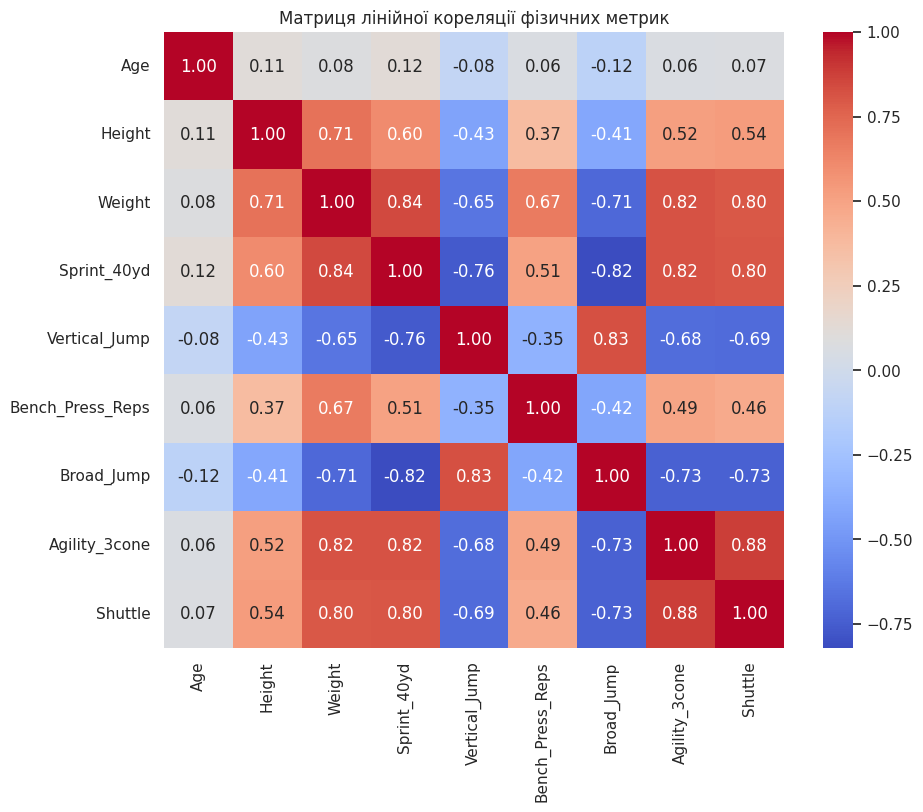


--- Кардинальність категоріальних ознак ---
School: 236 унікальних значень
Player_Type: 3 унікальних значень
Position_Type: 7 унікальних значень
Position: 20 унікальних значень


In [41]:
print("--- Співвідношення класів цільової змінної ---")
print(y.value_counts(normalize=True))

print("\n--- Виявлені пропуски в числових та категоріальних ознаках ---")
missing_data = X_train_raw.isnull().sum()
print(missing_data[missing_data > 0])

num_features = X_train_raw.select_dtypes(include=[np.number]).columns.drop(['Id', 'Year']).tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(X_train_raw[num_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Матриця лінійної кореляції фізичних метрик")
plt.show()

cat_features = ['School', 'Player_Type', 'Position_Type', 'Position']
print("\n--- Кардинальність категоріальних ознак ---")
for col in cat_features:
    print(f"{col}: {X_train_raw[col].nunique()} унікальних значень")

## Стійкий препроцесинг та Feature Engineering



In [42]:
X_train_raw['is_train'] = 1
test['is_train'] = 0
df = pd.concat([X_train_raw, test], ignore_index=True)

# Своєчасне приведення типів запобігає збоям ядра CatBoost при валідації
for col in cat_features:
    df[col] = df[col].fillna('Unknown').astype(str)

# Масштабування ознак через комбінацію фізичних параметрів
df['BMI'] = df['Weight'] / (df['Height'] ** 2)
df['Speed_Score'] = (df['Weight'] * 200) / (df['Sprint_40yd'] ** 4)
df['Jump_Power'] = df['Vertical_Jump'] * df['Broad_Jump']

# Запобігання витоку інформації через ізольовані позиційні агрегації
num_cols_to_aggr = ['Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle']
for col in num_cols_to_aggr:
    pos_mean = df.groupby('Position')[col].transform('mean')
    df[f'{col}_Pos_Mean'] = pos_mean.fillna(df[col].mean())
    df[f'{col}_Pos_Diff'] = (df[col] - df[f'{col}_Pos_Mean']).fillna(0)

X_train = df[df['is_train'] == 1].drop(['is_train', 'Id'], axis=1)
X_test = df[df['is_train'] == 0].drop(['is_train', 'Id'], axis=1)

## Валідація та навчання на K-Фолдах

In [43]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

oof_preds = np.zeros(len(X_train))
test_preds = np.zeros(len(X_test))

print("Запуск Stratified K-Fold...")

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train, y)):
    X_tr, y_tr = X_train.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X_train.iloc[valid_idx], y.iloc[valid_idx]

    train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
    valid_pool = Pool(X_va, y_va, cat_features=cat_features)

    # Обмеження thread_count стабілізує роботу та запобігає раптовому перериванню сесії (Aborted)
    model = CatBoostClassifier(
        iterations=1500,
        learning_rate=0.03,
        eval_metric='AUC',
        random_seed=RANDOM_STATE,
        use_best_model=True,
        early_stopping_rounds=100,
        verbose=100,
        thread_count=2
    )

    model.fit(train_pool, eval_set=valid_pool)

    oof_preds[valid_idx] = model.predict_proba(X_va)[:, 1]
    test_preds += model.predict_proba(X_test)[:, 1] / N_SPLITS

    fold_auc = roc_auc_score(y_va, oof_preds[valid_idx])
    print(f"Fold {fold+1} ROC-AUC: {fold_auc:.5f}\n")

cv_auc = roc_auc_score(y, oof_preds)
print(f"Overall Out-Of-Fold ROC-AUC: {cv_auc:.5f}")

Запуск Stratified K-Fold...
0:	test: 0.7826686	best: 0.7826686 (0)	total: 71.3ms	remaining: 1m 46s
100:	test: 0.8109277	best: 0.8118605 (96)	total: 2.22s	remaining: 30.8s
200:	test: 0.8117050	best: 0.8130618 (110)	total: 5.17s	remaining: 33.4s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.8130617898
bestIteration = 110

Shrink model to first 111 iterations.
Fold 1 ROC-AUC: 0.81306

0:	test: 0.7563392	best: 0.7563392 (0)	total: 23.4ms	remaining: 35.1s
100:	test: 0.8582002	best: 0.8582002 (99)	total: 4.43s	remaining: 1m 1s
200:	test: 0.8607714	best: 0.8609702 (190)	total: 6.88s	remaining: 44.5s
300:	test: 0.8630300	best: 0.8637545 (268)	total: 9.17s	remaining: 36.5s
400:	test: 0.8649336	best: 0.8658285 (321)	total: 11.9s	remaining: 32.7s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.865828539
bestIteration = 321

Shrink model to first 322 iterations.
Fold 2 ROC-AUC: 0.86583

0:	test: 0.7571134	best: 0.7571134 (0)	total: 49ms	remaining: 1m 13s

## Формування файлу для сабміту

In [44]:
# Копіювання структури оригінального шаблону для запобігання зсуву індексів Id
submission = sample_sub.copy()
submission['Drafted'] = test_preds

OUTPUT_PATH = DATA_DIR / 'catboost_baseline.csv'
submission.to_csv(OUTPUT_PATH, index=False)

print(f"Сабміт збережено у: {OUTPUT_PATH.resolve()}")
print(submission.head())

Сабміт збережено у: /content/drive/MyDrive/GCI/competition/catboost_baseline.csv
     Id   Drafted
0  2781  0.637235
1  2782  0.839524
2  2783  0.899136
3  2784  0.876979
4  2785  0.831156


## Опис ходу думок та інженерного підходу

### 1. Стратегія валідації
Для оцінки узагальнюючої здатності моделі було обрано метод Stratified 5-Fold крос-валідації. Це рішення базується на виявленому під час первинного аналізу дисбалансі класів (лише ~33% гравців отримують статус `Drafted`). Проста валідація на відкладеній вибірці призвела б до високої дисперсії оцінок метрики ROC-AUC. Орієнтація на середній Out-Of-Fold (OOF) скор захищає від перенавчання та забезпечує надійний критерій оцінки нових гіпотез.

### 2. Обробка пропусків та кодування категорій
У вихідних даних спостерігається значна кількість пропусків у специфічних фізичних тестах (наприклад, `Bench_Press_Reps`, `Agility_3cone`). Замість глобального заповнення середнім, що спотворює реальні профілі атлетів різних вагових категорій, було вирішено застосувати алгоритм CatBoost. Він здатний ефективно обробляти числові пропуски на рівні побудови вирішальних дерев та нативно працює з висококардинальними текстовими фічами (`School`), використовуючи внутрішній target-based統計 кодування всередині крос-валідаційних фолдів.

### 3. Генерація ознак (Feature Engineering)
Побудова нових фічей спиралася на спортивну логіку та метрики ефективності NFL Combine:
* **BMI:** Дозволяє оцінити щільність та комплекцію гравця.
* **Speed Score:** Важливий показник для беків та ресиверів, який нормує час спринту на 40 ярдів відносно ваги атлета (важчі гравці з високою швидкістю мають пріоритет).
* **Позиційні агрегації:** Фізичні параметри були нормалізовані через обчислення групових середніх для кожної ігрової позиції (`Position`). Це дозволяє моделі оцінювати гравця не взагалі, а відносно його прямих конкурентів за амплуа.

### Джерела та посилання:
1. Постановка задачі класифікації та опис фізичних тестів Combine — `README.ipynb` (Matsuo Lab, GCI World 2026).
2. Ідея ітеративної перевірки ознак через контроль OOF скору — `2_tutorial_feature_engineering.ipynb` (Matsuo Lab, Advanced Techniques).